# 2-Photon Calcium Imaging Binarization Pipeline

Demonstrates binarizing two-photon calcium data using `binarize2pcalcium`.
Uses the built-in simulation module to generate realistic GCaMP traces
with photon shot noise and slow baseline drift.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from binarize2pcalcium import binarize, BinarizationResult
from binarize2pcalcium.data_simulation import SimulationConfig, simulate_calcium_data

print("Setup complete.")

Setup complete.


## 1. Simulate realistic 2P data

`SimulationConfig.for_2p()` provides GCaMP6s kinetics, 30% dF/F peaks,
300-photon baselines, Poisson shot + Gaussian read noise, and slow drift.

In [ ]:
cfg = SimulationConfig.for_2p(amplitude_mean=0.50, event_rate=0.06)
F_noisy, dff_true = simulate_calcium_data(cfg)
print(f"F shape: {F_noisy.shape}  |  dF/F range: [{dff_true.min():.3f}, {dff_true.max():.3f}]")

F shape: (30, 9000)  |  dF/F range: [0.000, 0.880]


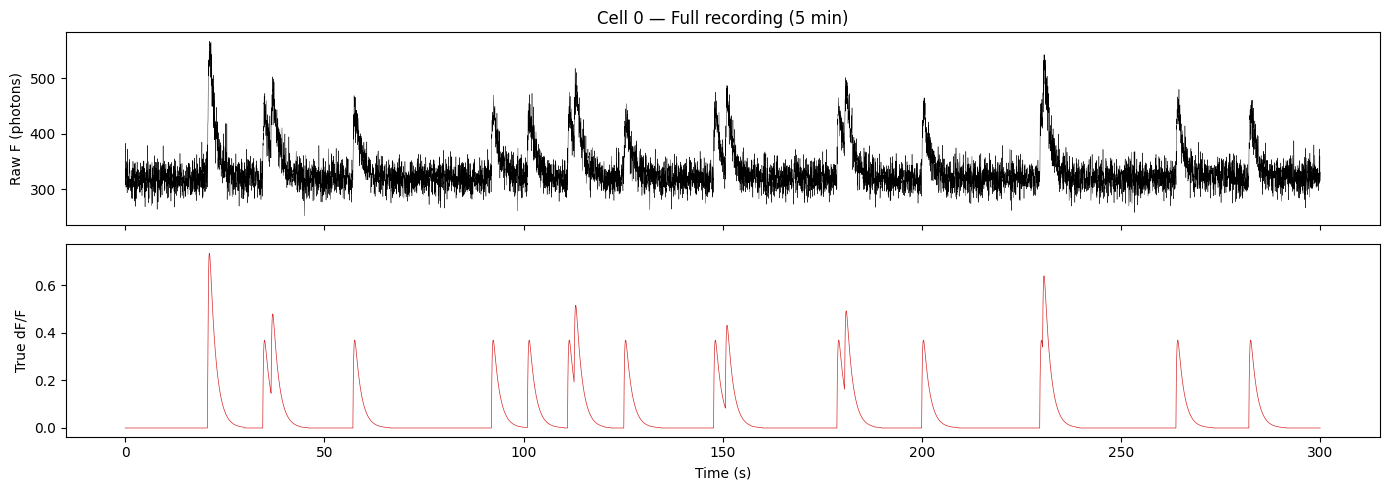

In [ ]:
cell_id = 0
t = np.arange(cfg.n_timepoints) / cfg.sample_rate
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t, F_noisy[cell_id], linewidth=0.3, color='k')
ax1.set_ylabel('Raw F (photons)'); ax1.set_title(f'Cell {cell_id} — Full recording (5 min)')
ax2.plot(t, dff_true[cell_id], linewidth=0.5, color='C3')
ax2.set_ylabel('True dF/F'); ax2.set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

## 2. Run the binarization pipeline

All values match `Calcium.set_default_parameters_2p()` from source.

In [ ]:
result = binarize(
    F_noisy,
    sample_rate=30,
    data_type='2p',
    high_cutoff=0.5,                # source default
    percentile_threshold=0.99999,   # source default
    dff_min=0.05,                   # source default
    min_width_onphase=30,           # source default
    min_width_upphase=10,           # source default
    remove_ends=False,              # source default
    verbose=True,
)

cells_on = (result.onphase.sum(axis=1) > 0).sum()
cells_up = (result.upphase.sum(axis=1) > 0).sum()
print(f"Onphase events: {result.onphase.sum():,}  ({cells_on} / {result.onphase.shape[0]} cells)")
print(f"Upphase events: {result.upphase.sum():,}  ({cells_up} / {result.upphase.shape[0]} cells)")

Running binarization pipeline:
  data_type=2p, sample_rate=30 Hz
  high_cutoff=0.5 Hz, detrend_order=1
  Input shape: (30, 9000)


model filter: remove bleaching or trends: 100%|██████████| 30/30 [00:00<00:00, 771.26it/s]

  Computing thresholds...



100%|██████████| 30/30 [00:02<00:00, 13.30it/s]


  Binarizing onphase...


binarizing continuous tracesfiltered fluorescence onphase: 100%|██████████| 30/30 [00:00<00:00, 8193.60it/s]


  Binarizing upphase...


binarizing continuous traces filtered fluorescence upphase: 100%|██████████| 30/30 [00:00<00:00, 6248.34it/s]

  Done. Onphase events: 61589, Upphase events: 14163
Onphase events: 61,589.0  (30 / 30 cells)
Upphase events: 14,163.0  (30 / 30 cells)


## 3. Full 5-minute overview

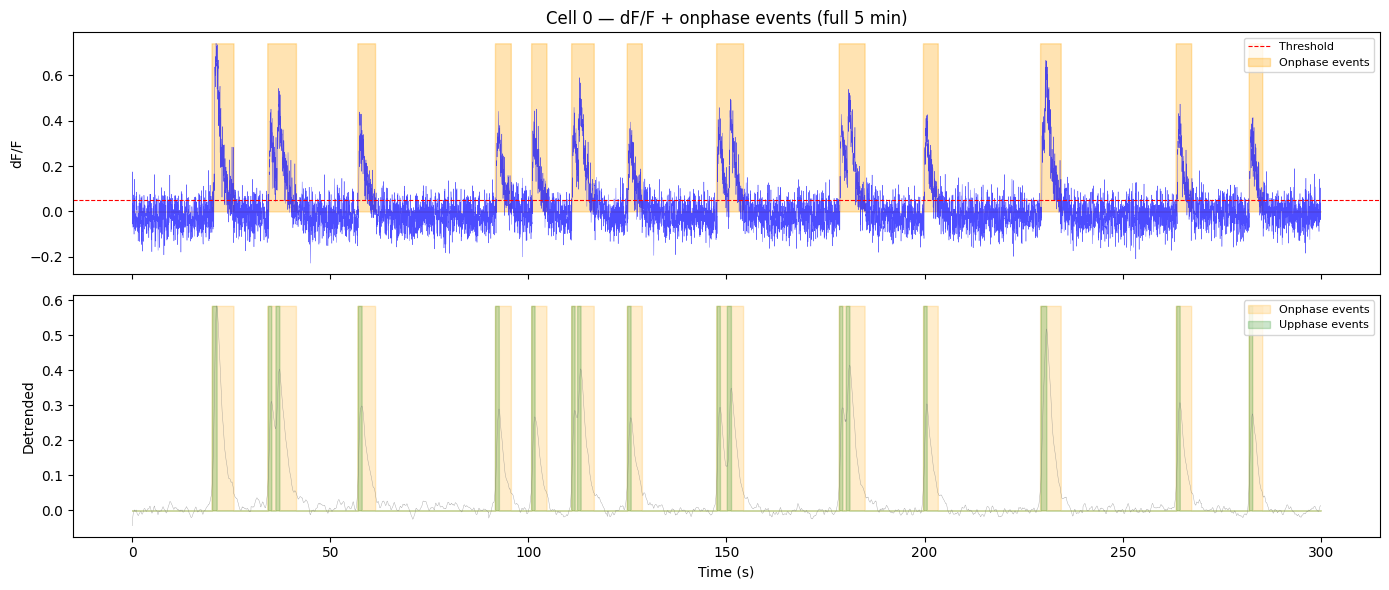

In [ ]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(t, result.dff[cell_id], 'b', linewidth=0.3, alpha=0.7)
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', linewidth=0.8, label='Threshold')
ymax = result.dff[cell_id].max()
ax1.fill_between(t, 0, result.onphase[cell_id] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax1.set_ylabel('dF/F'); ax1.set_title(f'Cell {cell_id} — dF/F + onphase events (full 5 min)')
ax1.legend(fontsize=8, loc='upper right')

ax2.plot(t, result.F_detrended[cell_id], 'gray', linewidth=0.3, alpha=0.7)
ymax = result.F_detrended[cell_id].max()
ax2.fill_between(t, 0, result.onphase[cell_id] * ymax,
                 alpha=0.2, color='orange', label='Onphase events')
ax2.fill_between(t, 0, result.upphase[cell_id] * ymax,
                 alpha=0.2, color='green', label='Upphase events')
ax2.set_ylabel('Detrended'); ax2.set_xlabel('Time (s)')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

## 4. Zoomed single-cell visualisation

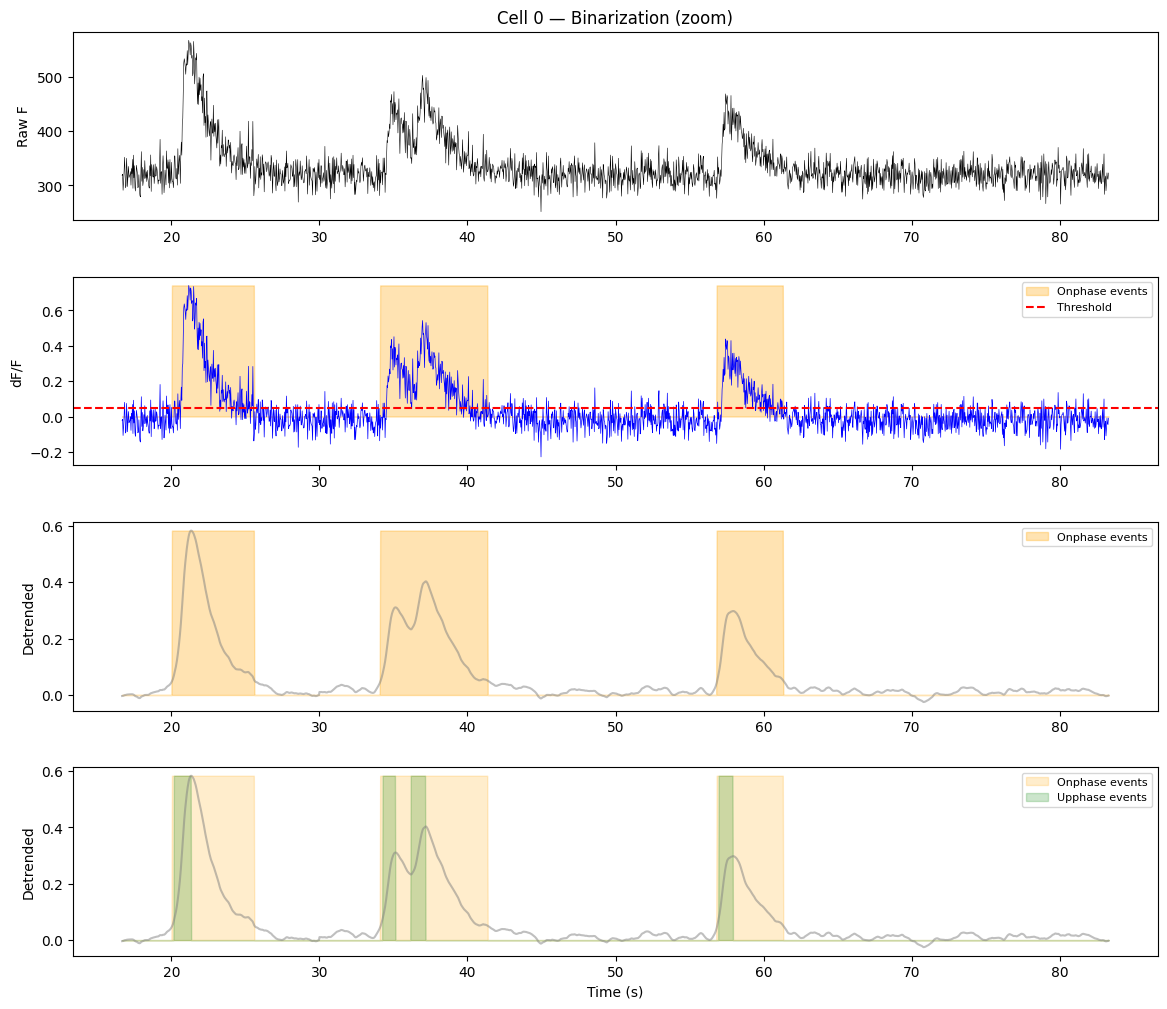

In [ ]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate
zoom = slice(500, 2500)

fig = plt.figure(figsize=(14, 12))
gs = GridSpec(4, 1, figure=fig, hspace=0.3)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t[zoom], result.F_raw[cell_id, zoom], 'k', linewidth=0.4)
ax0.set_ylabel('Raw F'); ax0.set_title(f'Cell {cell_id} — Binarization (zoom)')

ax1 = fig.add_subplot(gs[1])
ax1.plot(t[zoom], result.dff[cell_id, zoom], 'b', linewidth=0.5)
ymax = result.dff[cell_id, zoom].max()
ax1.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('dF/F'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[2])
ax2.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ymax = result.F_detrended[cell_id, zoom].max()
ax2.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase events')
ax2.set_ylabel('Detrended'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[3])
ax3.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ymax = result.F_detrended[cell_id, zoom].max()
ax3.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.2, color='orange', label='Onphase events')
ax3.fill_between(t[zoom], 0, result.upphase[cell_id, zoom] * ymax,
                 alpha=0.2, color='green', label='Upphase events')
ax3.set_ylabel('Detrended'); ax3.set_xlabel('Time (s)')
ax3.legend(fontsize=8)

plt.show()

## 5. Raster plot — all cells

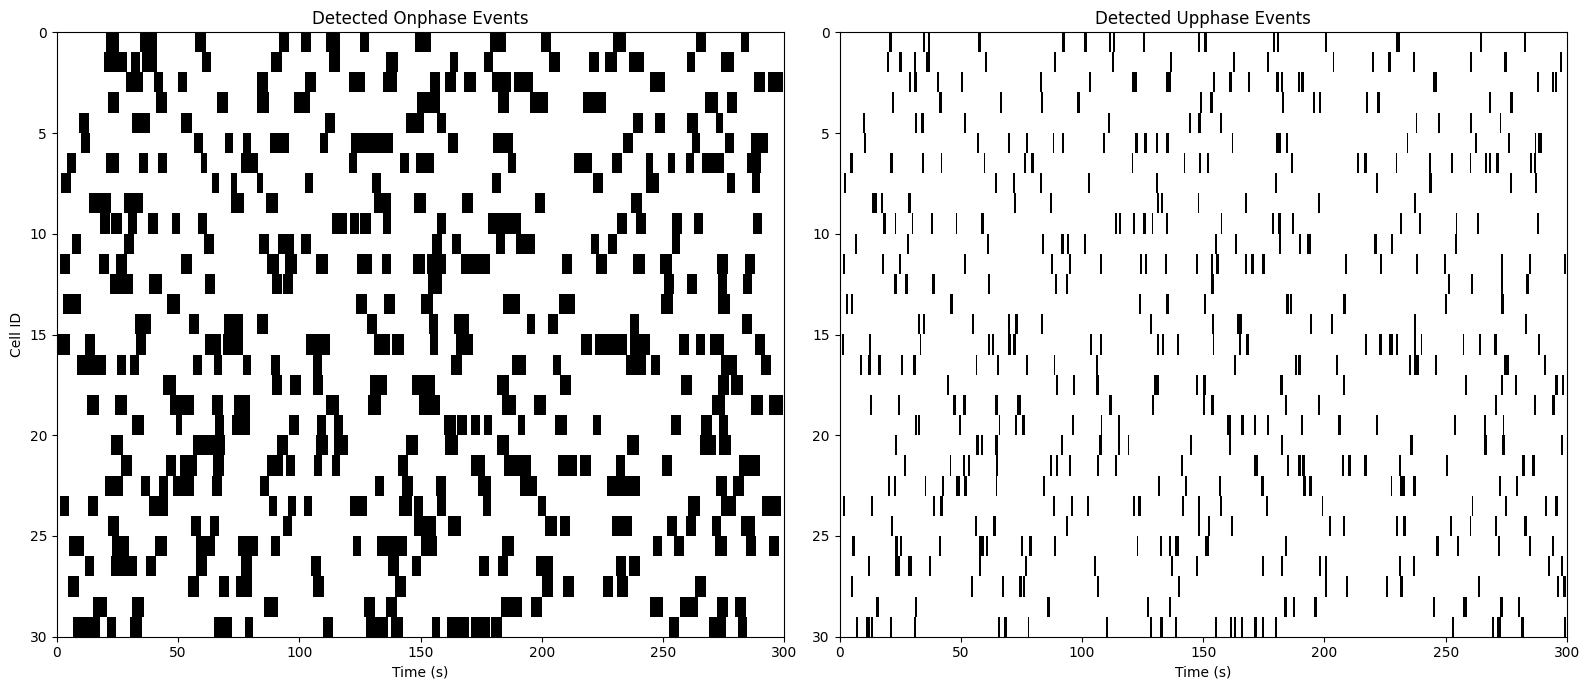

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.imshow(result.onphase, aspect='auto', cmap='Greys', interpolation='none',
          extent=[0, result.onphase.shape[1] / cfg.sample_rate, result.onphase.shape[0], 0])
ax.set_ylabel('Cell ID'); ax.set_xlabel('Time (s)')
ax.set_title('Detected Onphase Events')

ax = axes[1]
ax.imshow(result.upphase, aspect='auto', cmap='Greys', interpolation='none',
          extent=[0, result.upphase.shape[1] / cfg.sample_rate, result.upphase.shape[0], 0])
ax.set_xlabel('Time (s)')
ax.set_title('Detected Upphase Events')

plt.tight_layout(); plt.show()

## 6. Save / reload results

In [ ]:
result.save('binarized_2p_results.npz')
loaded = BinarizationResult.load('binarized_2p_results.npz')
assert np.array_equal(result.onphase, loaded.onphase)
print("Save / load verified.")

Save / load verified.
